In [1]:
# 8.6 Q2 - Spam Email Classification with SVM

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, accuracy_score,
    classification_report, precision_score, recall_score, f1_score)

In [3]:
df = pd.read_csv('datasets/spambase.csv')
print("Shape:", df.shape)
print(df.head())
print()
print("Class distribution (0 = not spam, 1 = spam):")
print(df['is_spam'].value_counts())

Shape: (4601, 58)
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_;  char_freq_(  \
0             0.00            0.00  ...         0.00 

In [4]:
y = df['is_spam']
X = df.drop(columns=['is_spam'])
print("X shape:", X.shape, "y shape:", y.shape)

X shape: (4601, 57) y shape: (4601,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (3220, 57) Test: (1381, 57)


In [6]:
sc = StandardScaler()
X_train_s = sc.fit_transform(X_train)
X_test_s  = sc.transform(X_test)
print("Standardised.")

Standardised.


In [7]:
# Train SVM with Linear kernel (fast on high-dim data)

In [8]:
model = SVC(kernel='linear', random_state=0)
model.fit(X_train_s, y_train)
y_pred = model.predict(X_test_s)

print("Accuracy  :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall    :", recall_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam']))

Accuracy  : 0.9290369297610427
Precision : 0.9160447761194029
Recall    : 0.9025735294117647
F1 Score  : 0.9092592592592592

              precision    recall  f1-score   support

    Not Spam       0.94      0.95      0.94       837
        Spam       0.92      0.90      0.91       544

    accuracy                           0.93      1381
   macro avg       0.93      0.92      0.93      1381
weighted avg       0.93      0.93      0.93      1381



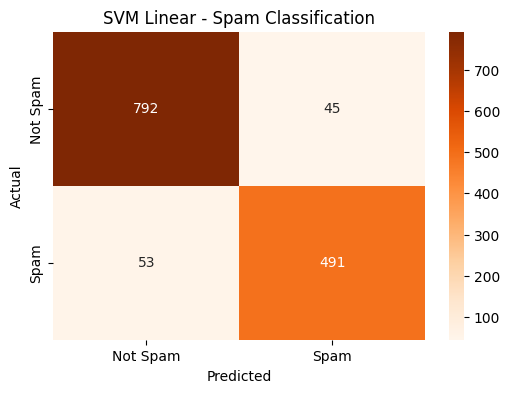

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Linear - Spam Classification')
plt.show()

In [10]:
# Compare kernels

  linear   acc=0.9290  recall=0.9026  f1=0.9093


  rbf      acc=0.9276  recall=0.8879  f1=0.9062


  poly     acc=0.7705  recall=0.4412  f1=0.6023

   Kernel  Accuracy    Recall        F1
0  linear  0.929037  0.902574  0.909259
1     rbf  0.927589  0.887868  0.906191
2    poly  0.770456  0.441176  0.602258


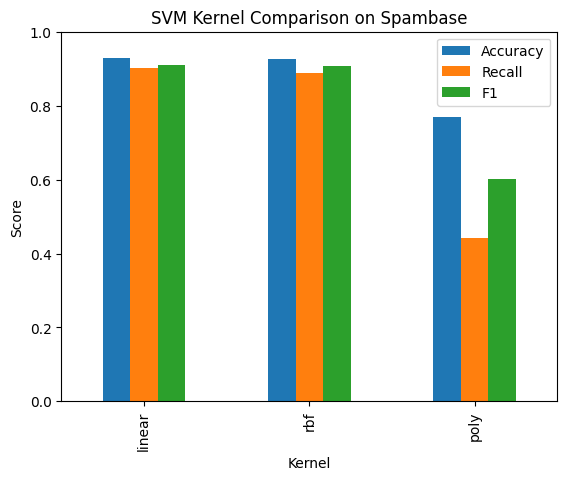

In [11]:
results = []
for kernel in ['linear', 'rbf', 'poly']:
    m = SVC(kernel=kernel, random_state=0)
    m.fit(X_train_s, y_train)
    yp = m.predict(X_test_s)
    a = accuracy_score(y_test, yp)
    r = recall_score(y_test, yp)
    f = f1_score(y_test, yp)
    results.append({'Kernel': kernel, 'Accuracy': a, 'Recall': r, 'F1': f})
    print("  " + kernel.ljust(8), "acc=%.4f  recall=%.4f  f1=%.4f" % (a, r, f))

cmp = pd.DataFrame(results)
print()
print(cmp)

cmp.set_index('Kernel')[['Accuracy','Recall','F1']].plot.bar()
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('SVM Kernel Comparison on Spambase')
plt.show()